# **Module : 11**
# **Assignment : Diabetes Prediction Model**
#**Student Name : Farjana Ferdausi**
##**Course : AI/ML Engineering Bootcamp, Batch: 6, Ostad**

#**Answer:**

#**Dataset : Pima Indians Diabetes Database**  
#**Objective : Predict diabetes using medical attributes**

#1️⃣Import all required libraries :

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
)
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
%matplotlib inline

#2️⃣Data Loading & Exploration :

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Shape of dataset: (768, 9)

Zeros in key columns (likely missing data):
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Missing values (NaN count):
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Statistical summary:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000



Class distribution (Outcome):
Outcome
0    500
1    268
Name: count, dtype: int64


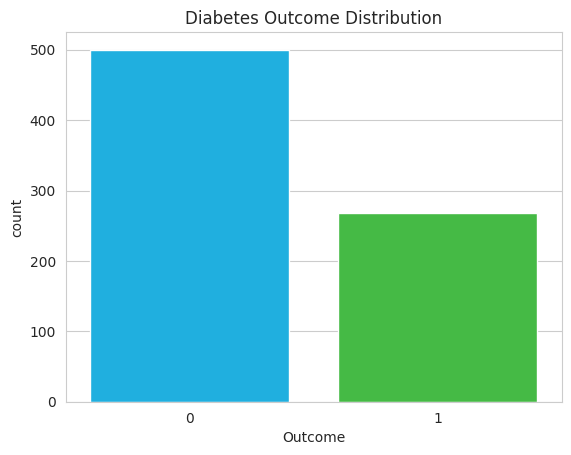

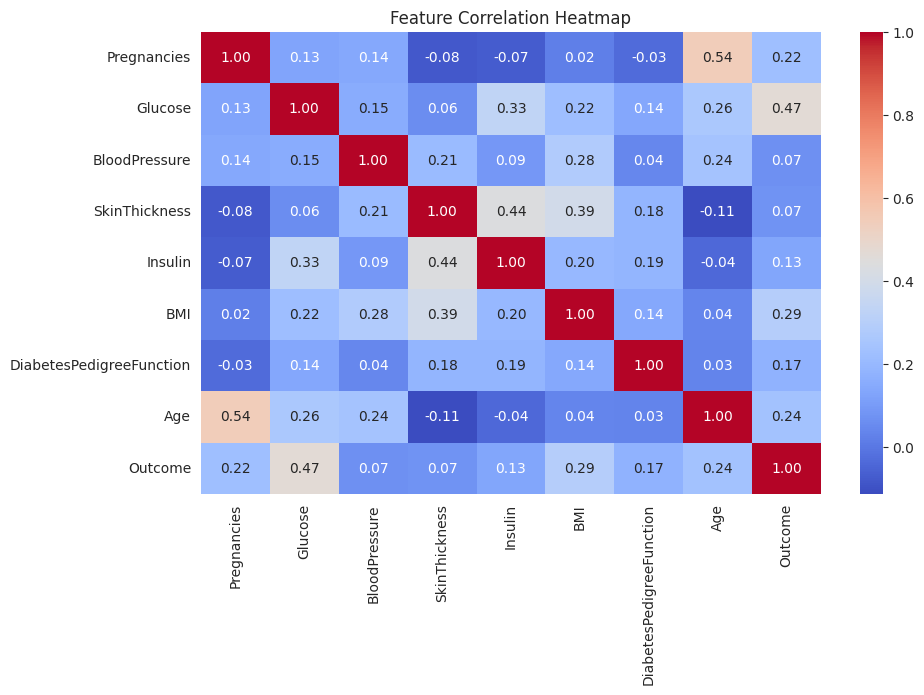

In [2]:
# Load dataset and explore
# Load with column names

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'
]
df = pd.read_csv(url, names=columns)

# First few rows
print("First 5 rows:")
display(df.head())

# Shape
print("\nShape of dataset:", df.shape)

# Check for zeros that are biologically impossible → indicates missing data
print("\nZeros in key columns (likely missing data):")
cols_check = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
zero_counts = (df[cols_check] == 0).sum()
print(zero_counts)

print("\nMissing values (NaN count):")
print(df.isnull().sum())

# Basic statistics
print("\nStatistical summary:")
display(df.describe())

# Class distribution (fixed colours — bright blue & green)
print("\nClass distribution (Outcome):")
print(df['Outcome'].value_counts())
sns.countplot(x='Outcome', data=df, hue='Outcome',
              palette={0: '#00BFFF', 1: '#32CD32'}, legend=False)
plt.title('Diabetes Outcome Distribution')
plt.show()

# Correlation heatmap (extra insight)
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

#**Observation :**
###Several medically critical columns (`Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`) contain zeros, which are physiologically impossible. These zeros indicate missing data. We will replace them with the `median` of the training set to avoid data leakage and preserve distribution.

#3️⃣Data Preprocessing :

In [3]:
# Separate features and target

X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Train-test split (80/20) with stratification

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Columns where zeros indicate missing data

cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Impute zeros with the median computed ONLY from training data

for col in cols_with_zeros:
    # Compute median of the training column after temporarily replacing zeros with NaN
    train_median = X_train[col].replace(0, np.nan).median()
    # Replace zeros in both train and test sets with this median
    X_train[col] = X_train[col].replace(0, train_median)
    X_test[col]  = X_test[col].replace(0, train_median)

# Check if any zero remains
print("Zeros after imputation (Train):", (X_train[cols_with_zeros] == 0).sum().sum())
print("Zeros after imputation (Test):", (X_test[cols_with_zeros] == 0).sum().sum())

print("\nTraining set size:", X_train.shape)
print("Test set size:", X_test.shape)

# Feature scaling (fit on train, transform both)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Zeros after imputation (Train): 0
Zeros after imputation (Test): 0

Training set size: (614, 8)
Test set size: (154, 8)


#4️⃣Model Training : Train four classification models


In [4]:
# Model Training – Logistic Regression, Random Forest, SVM, KNN

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'SVM (RBF)': SVC(probability=True, random_state=42),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5)
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    print(f"{name} trained.")

Logistic Regression trained.
Random Forest trained.
SVM (RBF) trained.
KNN (k=5) trained.


#5️⃣ Model Evaluation : All Metrics

In [5]:
# Evaluate all models - Accuracy, Precision, Recall, F1, ROC-AUC

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    print(f"--- {name} ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}\n")
    return auc

auc_scores = {}
for name, model in trained_models.items():
    auc_scores[name] = evaluate_model(name, model, X_test_scaled, y_test)

--- Logistic Regression ---
Accuracy : 0.7078
Precision: 0.6000
Recall   : 0.5000
F1 Score : 0.5455
ROC-AUC  : 0.8130

--- Random Forest ---
Accuracy : 0.7727
Precision: 0.7021
Recall   : 0.6111
F1 Score : 0.6535
ROC-AUC  : 0.8181

--- SVM (RBF) ---
Accuracy : 0.7403
Precision: 0.6522
Recall   : 0.5556
F1 Score : 0.6000
ROC-AUC  : 0.7964

--- KNN (k=5) ---
Accuracy : 0.7532
Precision: 0.6600
Recall   : 0.6111
F1 Score : 0.6346
ROC-AUC  : 0.7899



#6️⃣Confusion Matrices (Visual) :

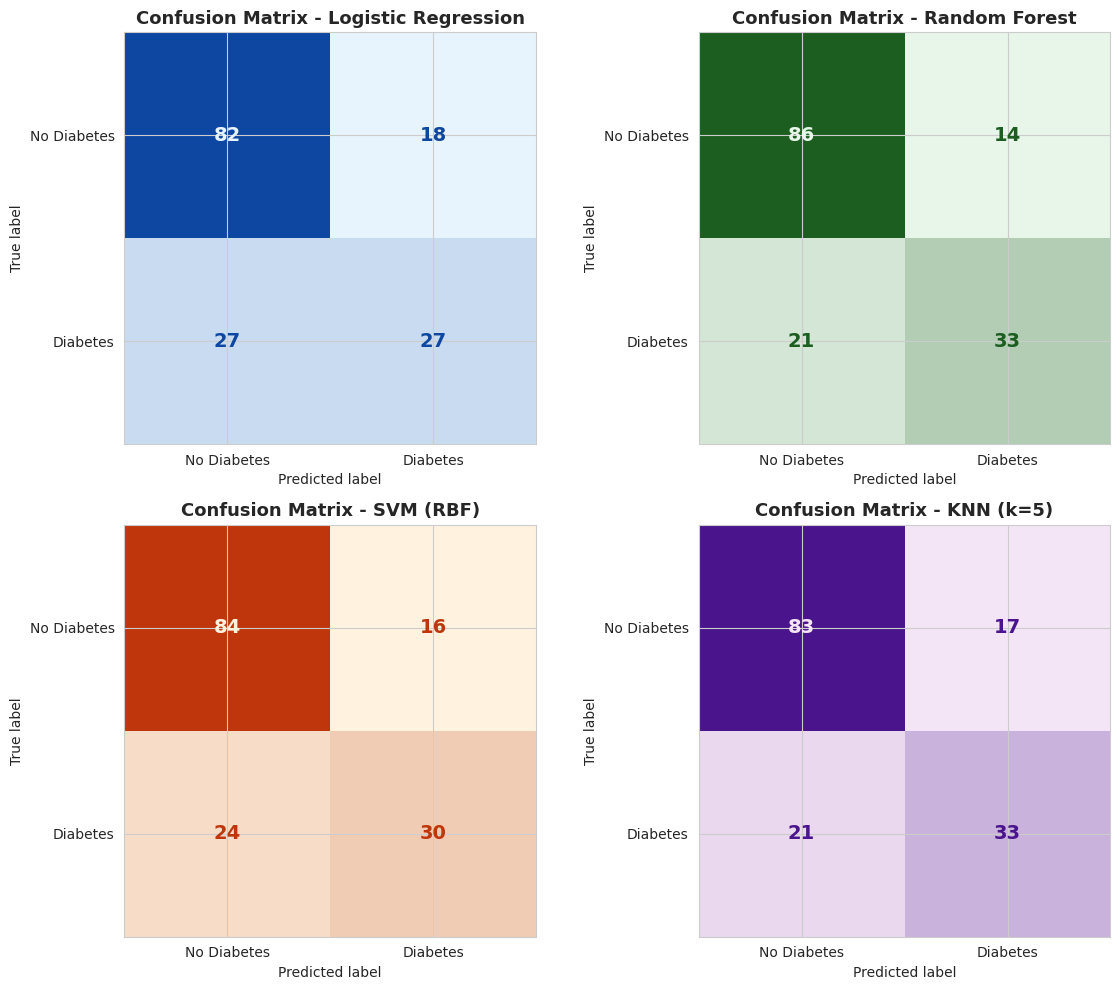

In [6]:
# Confusion matrices for all models
from matplotlib.colors import LinearSegmentedColormap

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

custom_cmaps = [
    LinearSegmentedColormap.from_list('custom_blues', ['#E8F4FD', '#0D47A1']),   # Light sky to Dark navy blue
    LinearSegmentedColormap.from_list('custom_greens', ['#E8F5E9', '#1B5E20']), # Light mint to Dark green
    LinearSegmentedColormap.from_list('custom_oranges', ['#FFF3E0', '#BF360C']),# Light peach to Dark burnt orange
    LinearSegmentedColormap.from_list('custom_purples', ['#F3E5F5', '#4A148C'])# Light lavender to Dark indigo
]

for idx, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Diabetes', 'Diabetes'])

    disp.plot(ax=axes[idx], cmap=custom_cmaps[idx], colorbar=False,
              text_kw={'fontsize': 14, 'fontweight': 'bold'})
    axes[idx].set_title(f'Confusion Matrix - {name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#7️⃣ ROC Curves :

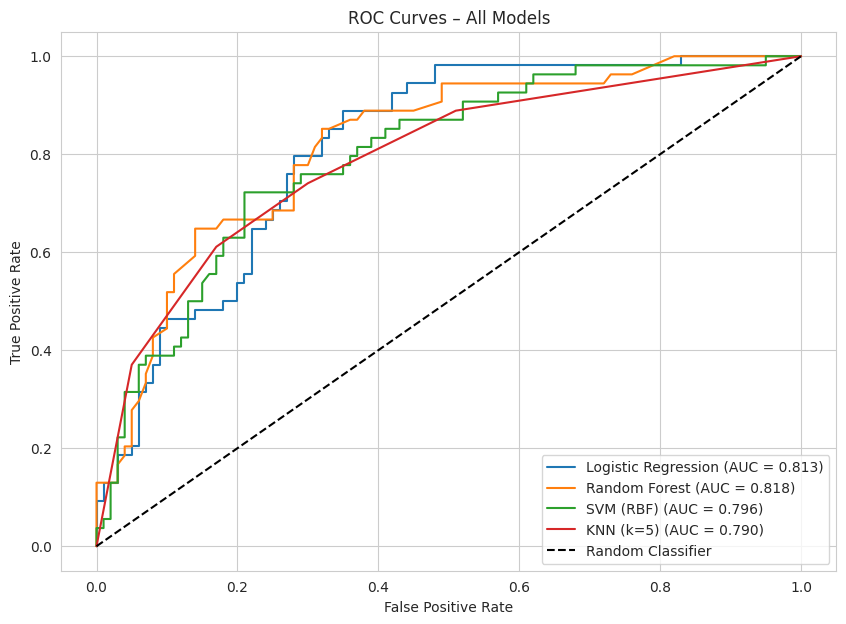

In [7]:
# ROC curves comparison
plt.figure(figsize=(10, 7))
for name, model in trained_models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_scores[name]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves – All Models')
plt.legend()
plt.show()

#8️⃣Feature Importance (Random Forest) :

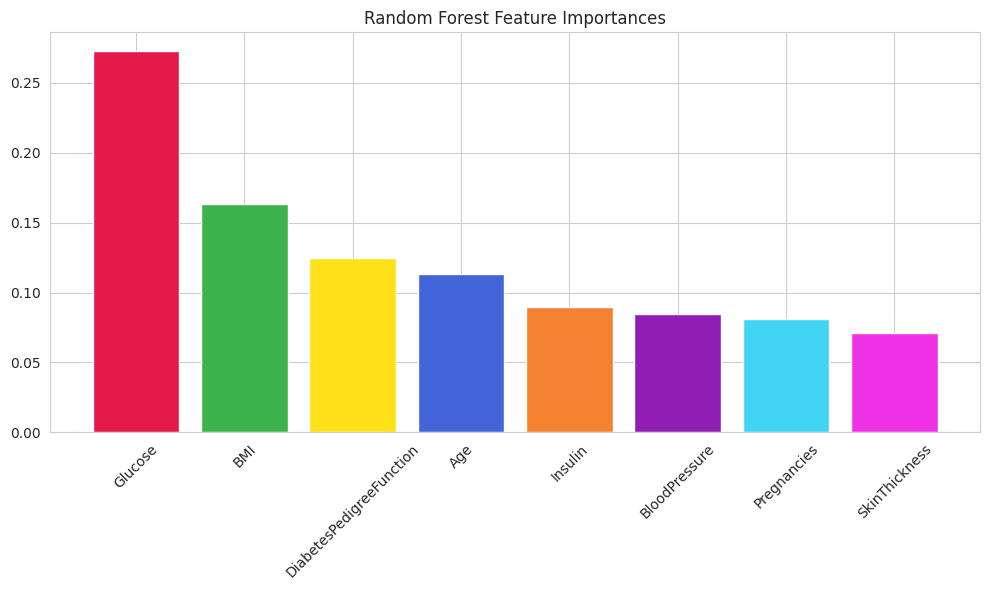

In [8]:
# Random Forest Feature Importance
rf_model = trained_models['Random Forest']
importances = rf_model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

colors = ['#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#42d4f4', '#f032e6']

plt.figure(figsize=(10, 6))
bars = plt.bar(range(len(importances)), importances[indices], color=colors)
plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=45)
plt.title('Random Forest Feature Importances')
plt.tight_layout()
plt.show()

#9️⃣Cross-Validation (AUC) :

In [9]:
# 5-fold Cross-Validation ROC-AUC

print("5-fold Cross-Validation ROC-AUC:")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_means = {}   # This dictionary wasn't created before, creating now

for name, model in trained_models.items():
    cv_auc = cross_val_score(model, X_train_scaled, y_train,
                             cv=cv, scoring='roc_auc')
    cv_means[name] = cv_auc.mean()   # storing the mean score
    print(f"{name}: {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")

5-fold Cross-Validation ROC-AUC:
Logistic Regression: 0.8428 ± 0.0190
Random Forest: 0.8183 ± 0.0216
SVM (RBF): 0.8337 ± 0.0220
KNN (k=5): 0.7830 ± 0.0383


#1️⃣0️⃣Best Model Selection & Save :

In [10]:
# Select and save the best model based on Cross-Validation ROC-AUC
# Using CV to avoid overfitting to the test set during model selection

best_model_name = max(cv_means, key=cv_means.get)
best_model = trained_models[best_model_name]
print(f"Best model based on 5-fold CV ROC-AUC: {best_model_name} ({cv_means[best_model_name]:.4f})")

# Save best model and scaler
joblib.dump(best_model, "diabetes_model.pkl")
joblib.dump(scaler, "scaler.pkl")
print("Best model saved as 'diabetes_model.pkl'")
print("Scaler saved as 'scaler.pkl'")

# Quick verification
loaded_model = joblib.load("diabetes_model.pkl")
loaded_scaler = joblib.load("scaler.pkl")
sample = X_test.iloc[0:1]  # same sample as before, prediction may differ with new model
sample_scaled = loaded_scaler.transform(sample)
pred = loaded_model.predict(sample_scaled)[0]
prob = loaded_model.predict_proba(sample_scaled)[0][1]
print(f"Verification: true label={y_test.iloc[0]}, predicted={pred}, probability={prob:.4f}")

Best model based on 5-fold CV ROC-AUC: Logistic Regression (0.8428)
Best model saved as 'diabetes_model.pkl'
Scaler saved as 'scaler.pkl'
Verification: true label=0, predicted=1, probability=0.6097
